In [2]:
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import os
import glob
import time
stage3_start = time.perf_counter()
timing_rows = []

secondStagepreprocess/balancedsecondstage\complexitymetaDataset.csv
complexitymetaDataset.csv => shape: (176, 5), nulls: 0
Cross-validated accuracy: 0.8751633986928103
StackingClassifier avg accuracy: 0.886
Finished complexitymetaDataset.csv in 116.63 sec
GeneralMetaDatset.csv => shape: (180, 12), nulls: 0
Cross-validated accuracy: 0.888888888888889
StackingClassifier avg accuracy: 0.894
Finished GeneralMetaDatset.csv in 99.93 sec
infotheoryMetaDataset.csv => shape: (180, 10), nulls: 0
Cross-validated accuracy: 0.9277777777777777
StackingClassifier avg accuracy: 0.944
Finished infotheoryMetaDataset.csv in 80.89 sec


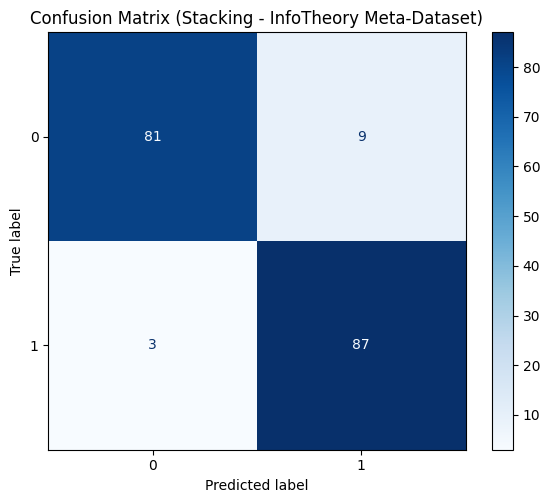

landmarkMeta.csv => shape: (180, 9), nulls: 0
Cross-validated accuracy: 0.9055555555555556
StackingClassifier avg accuracy: 0.917
Finished landmarkMeta.csv in 105.98 sec
modelBasedMeta.csv => shape: (180, 16), nulls: 0
Cross-validated accuracy: 0.8555555555555555
StackingClassifier avg accuracy: 0.878
Finished modelBasedMeta.csv in 164.15 sec
statisticalMetaDataset.csv => shape: (180, 17), nulls: 0
Cross-validated accuracy: 0.8722222222222221
StackingClassifier avg accuracy: 0.906
Finished statisticalMetaDataset.csv in 113.64 sec


In [3]:
from matplotlib import pyplot as plt
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import cross_val_predict

folder_path = "secondStagepreprocess/balancedsecondstage"
csv_files = glob.glob(folder_path + "/*.csv")  # Adjust for different file types
file_names = [os.path.basename(file) for file in csv_files]

print(csv_files[0])
mydata=0
outputKNNList=[]
outputGNBList=[]
outputSVCList=[]
outputlRList=[]
outputDTList=[]
outputGBCList=[]
outputRFList=[]
voting_accuracy=[]
stackingACC=[]
AccDataset={}
algAccOut={}

for i in range(len(file_names)):
    dataset_start = time.perf_counter()
    mydata = pd.read_csv(folder_path + "/" + file_names[i])
    print(f"{file_names[i]} => shape: {mydata.shape}, nulls: {mydata.isnull().sum().sum()}")
    
    if mydata.isnull().values.any() or len(mydata.columns) < 3:
        print(f"⛔ Skipping {file_names[i]} due to nulls or insufficient columns.")
        continue

    x = mydata.iloc[:, 1:-1].to_numpy()
    y = mydata.iloc[:, -1].to_numpy()

    if len(np.unique(y)) < 2:
        print(f"⛔ Skipping {file_names[i]} due to only one class in target.")
        continue

    # Continue with fitting classifiers...

    individual_start = time.perf_counter()
    # Create KNN classifier
    knn = KNeighborsClassifier(n_neighbors = 5)
    KNNscores=cross_val_score(knn,x,y,cv=10,scoring='accuracy' )
    
    #printing avg score
    avgKNNscores=round(np.mean(KNNscores),4)*100
    outputKNNList.append(avgKNNscores)
   # print("Knn Avg scores",avgKNNscores)
    #Create GaussianNB classifier
    gnb = GaussianNB()
    gnbscores=cross_val_score(gnb,x,y,cv=10,scoring='accuracy' )
    #print("GNB scores",gnbscores)
    avgGNBscores=round(np.mean(gnbscores),4)*100
    outputGNBList.append(avgGNBscores)
    #print("GNB Avg scores",avgGNBscores)
    #create SVC(support vector classifier
    Svc=SVC(probability=True)
    SVCscores=cross_val_score(Svc,x,y,cv=10,scoring='accuracy')
    avgSVCscores=round(np.mean(SVCscores),4)*100
    outputSVCList.append(avgSVCscores)
    
    #logistic Regresion
    # instantiate & fit
    lr=LogisticRegression(max_iter=1000)
    LrScore=cross_val_score(lr,x,y,cv=10,scoring='accuracy' )
    avglrScore=round(np.mean(LrScore),4)*100
    #print('lrscore',avglrScore)
    outputlRList.append(avglrScore)
    
    #Desion tree
    DT = DecisionTreeClassifier(min_samples_split=10,max_depth=3)
    DTScore=cross_val_score(DT,x,y,cv=10, scoring='accuracy')
    avgDTScore=round(np.mean(DTScore),4)*100
    #print('avgDtscore',avgDTScore)
    outputDTList.append(avgDTScore)

    #Random forest
# instantiate & fit
    RF = RandomForestClassifier(n_estimators=300,max_depth=3)
    RFScore=cross_val_score(RF,x,y,cv=10 ,scoring='accuracy')
    avgRFScore=round(np.mean(RFScore),4)*100
    #print('avgRFScore',avgRFScore)
    outputRFList.append(avgRFScore)
    
    #Gradient boosting
    gbc = GradientBoostingClassifier(n_estimators=100)
    GBCScore=cross_val_score(gbc,x,y,cv=10 ,scoring='accuracy')
    avgGBCScore=round(np.mean(GBCScore),4)*100
    #print('avgGBCScore',avgGBCScore)
    outputGBCList.append(avgGBCScore)
    
    individual_end = time.perf_counter()
    timing_rows.append({
        "DatasetName": file_names[i],
        "Block": "Individual Meta-Learners",
        "Execution_Time_sec": individual_end - individual_start
    })
    voting_start = time.perf_counter()
    #Cross Val byvoting 
    voting = VotingClassifier(estimators=[
        ('KNN', knn), ('Gnb', gnb),('svc',Svc),('lr',lr),('dt',DT)
        ,('rf',RF),('GBC',gbc)
    ], voting='hard',weights=[1,1,1,1,1,1,10])
    
    scores = cross_val_score(voting, x, y, cv=10)
    voting_accuracy.append(round(scores.mean(),4)*100)
    print("Cross-validated accuracy:", scores.mean())
    
    voting_end = time.perf_counter()
    timing_rows.append({
        "DatasetName": file_names[i],
        "Block": "Voting",
        "Execution_Time_sec": voting_end - voting_start
    })
    stacking_start = time.perf_counter()
#stacking ensemble classifier 
    # Define meta-model
    meta_model = LogisticRegression(max_iter=1000)
    # Build stacking model
    stacking_clf = StackingClassifier(
    estimators=[
        ('KNN', knn), ('Gnb', gnb),('svc',Svc),('lr',lr),('dt',DT)
        ,('rf',RF),('GBC',gbc)],
    final_estimator=meta_model,
    passthrough=True,
    cv=10  # cross-validation inside stacking
    )

# تدريب أو cross-validation:
    scores = cross_val_score(stacking_clf, x, y, cv=10, scoring='accuracy')
    stackingACC.append(round(scores.mean(), 4)*100)
    print("StackingClassifier avg accuracy:", round(scores.mean(), 3))

    stacking_end = time.perf_counter()
    timing_rows.append({
        "DatasetName": file_names[i],
        "Block": "Stacking",
        "Execution_Time_sec": stacking_end - stacking_start
    })

    # =========================
    # Total time for this dataset
    # =========================
    dataset_end = time.perf_counter()
    timing_rows.append({
        "DatasetName": file_names[i],
        "Block": "Dataset Total",
        "Execution_Time_sec": dataset_end - dataset_start
    })

    print(f"Finished {file_names[i]} in {dataset_end - dataset_start:.2f} sec")
    # Generate predictions using cross-validation
    y_pred = cross_val_predict(stacking_clf, x, y, cv=10)

    if file_names[i] == "infotheoryMetaDataset.csv":
        class_labels = np.unique(y)
        cm = confusion_matrix(y, y_pred, labels=class_labels)

        fig, ax = plt.subplots(figsize=(6, 5))

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=class_labels
        )
        disp.plot(
            cmap='Blues',
            values_format='d',
            ax=ax,
            colorbar=True
        )

        ax.set_title("Confusion Matrix (Stacking - InfoTheory Meta-Dataset)")
        plt.tight_layout()
        plt.savefig("confusion_matrix_stacking_infotheory.png", dpi=300, bbox_inches='tight')
        plt.show()


In [4]:
AccDataset = {}
inner_keys = ['KNN', 'GNB', 'SVC', 'LR', 'DT', 'RF','GBC','voting', 'stacking'
               ]
values = [outputKNNList,outputGNBList,outputSVCList,outputlRList,outputDTList,outputRFList,outputGBCList,voting_accuracy,stackingACC
           ]
# تأكد إن عدد الملفات = عدد النتائج في القوائم
print(len(file_names))            # كم ملف عندك
print(len(outputKNNList))         # طول كل قائمة دقة
  
for idx, outer_key in enumerate(file_names):
    AccDataset[outer_key] = {}
    for i in range(len(inner_keys)):
        AccDataset[outer_key][inner_keys[i]] = values[i][idx]
print(AccDataset)

6
6
{'complexitymetaDataset.csv': {'KNN': np.float64(74.92999999999999), 'GNB': np.float64(64.14999999999999), 'SVC': np.float64(73.27), 'LR': np.float64(64.14999999999999), 'DT': np.float64(72.78), 'RF': np.float64(75.56), 'GBC': np.float64(86.96000000000001), 'voting': np.float64(87.52), 'stacking': np.float64(88.63)}, 'GeneralMetaDatset.csv': {'KNN': np.float64(76.11), 'GNB': np.float64(50.56), 'SVC': np.float64(54.44), 'LR': np.float64(55.559999999999995), 'DT': np.float64(71.67), 'RF': np.float64(78.89), 'GBC': np.float64(88.33), 'voting': np.float64(88.89), 'stacking': np.float64(89.44)}, 'infotheoryMetaDataset.csv': {'KNN': np.float64(78.33), 'GNB': np.float64(61.11), 'SVC': np.float64(65.56), 'LR': np.float64(65.56), 'DT': np.float64(68.89), 'RF': np.float64(75.56), 'GBC': np.float64(91.11), 'voting': np.float64(92.78), 'stacking': np.float64(94.44)}, 'landmarkMeta.csv': {'KNN': np.float64(80.0), 'GNB': np.float64(77.22), 'SVC': np.float64(80.56), 'LR': np.float64(79.44), 'DT':

In [5]:
#['LR', 'SVC', 'GBC', 'GBC', 'GBC', 'GNB', 'LR', 'LR', 'KNN', 'SVC', 'KNN', 'RF']
maxAlgNames=[]
maxAlgAcc=[]
for dataName,algName in AccDataset.items():
    print(dataName,algName)
    for nameMaxalg in AccDataset[dataName]:
         print(max(AccDataset[dataName].values()))
         if AccDataset[dataName][nameMaxalg] == max(AccDataset[dataName].values()): 
             maxAlgNames.append(nameMaxalg)
             maxAlgAcc.append(max(AccDataset[dataName].values()))
             break
            
         
           
            
print(maxAlgNames)
print(maxAlgAcc)


    #saving  output in file
data = {
    'DatasetName': file_names,
    'KNN': outputKNNList,
    'GNB':outputGNBList,
    'SVC':outputSVCList,
    'LR':outputlRList,
    'DT':outputDTList,
    'RF':outputRFList,
    'GBC':outputGBCList,
    'ensemblevoting':voting_accuracy,
    'stacking':stackingACC,
    'max Acc':maxAlgAcc,
    'maxtechNames':maxAlgNames,
    
    
}
print(len(outputKNNList))
print(len(outputGNBList))
print(len(outputSVCList))
print(len(outputlRList))
print(len(outputDTList))
print(len(outputRFList))
print(len(outputGBCList))
print(len(maxAlgAcc))
print(len(maxAlgNames))
out_data=pd.DataFrame(data)
print(out_data)
file_name = 'outputs/secondStageOutData7metalearnerwith voting vs stacking accuracy ratio.csv'
out_data.to_csv(file_name)
print('DataFrame is written to Excel File successfully.')

stage3_end = time.perf_counter()
stage3_total = stage3_end - stage3_start


timing_rows.append({
    "DatasetName": "All Meta-Datasets",
    "Block": "Stage 3 Total",
    "Execution_Time_sec": stage3_total
})

timing_df = pd.DataFrame(timing_rows)
timing_df["Execution_Time_min"] = (timing_df["Execution_Time_sec"] / 60).round(2)

print(timing_df)
timing_df.to_csv("stage3_time.csv", index=False)

print("Stage 3 Total Time:", round(stage3_total / 60, 2), "minutes")
    

complexitymetaDataset.csv {'KNN': np.float64(74.92999999999999), 'GNB': np.float64(64.14999999999999), 'SVC': np.float64(73.27), 'LR': np.float64(64.14999999999999), 'DT': np.float64(72.78), 'RF': np.float64(75.56), 'GBC': np.float64(86.96000000000001), 'voting': np.float64(87.52), 'stacking': np.float64(88.63)}
88.63
88.63
88.63
88.63
88.63
88.63
88.63
88.63
88.63
GeneralMetaDatset.csv {'KNN': np.float64(76.11), 'GNB': np.float64(50.56), 'SVC': np.float64(54.44), 'LR': np.float64(55.559999999999995), 'DT': np.float64(71.67), 'RF': np.float64(78.89), 'GBC': np.float64(88.33), 'voting': np.float64(88.89), 'stacking': np.float64(89.44)}
89.44
89.44
89.44
89.44
89.44
89.44
89.44
89.44
89.44
infotheoryMetaDataset.csv {'KNN': np.float64(78.33), 'GNB': np.float64(61.11), 'SVC': np.float64(65.56), 'LR': np.float64(65.56), 'DT': np.float64(68.89), 'RF': np.float64(75.56), 'GBC': np.float64(91.11), 'voting': np.float64(92.78), 'stacking': np.float64(94.44)}
94.44
94.44
94.44
94.44
94.44
94.44
9